# Tutorial for Real-World Data
This tutorial offers a step-by-step guide to replicating the real-world results shown in our paper. Please make sure you have downloaded the required datasets from our repository before executing the code. Some important parameters in our model are:

- `interpretable`: Whether or not to use interpretable mode of SpaMV.
- `max_epoch_stage1`: the maximum number of epoches for the first stage of SpaMV.
- `max_epoch_stage2`: the maximum number of epoches for the second stage of SpaMV (only useful for interpretable dimension reduction mode).
- `weights`: the hyperparameters that re-weight the reconstruction loss for different modalities. A higher value for one modality would lead the model values that modality more than others.
- `alphas`: the hyperparameters that regulate the strength of the uniqueness constraint on the private latent variables.


## Domain Clustering on Real-World Data
In this section, we demonstrate the training procedure and clustering outcomes for the four real-world datasets featured in our paper. We applied distinct preprocessing methods for various omics data types, implemented in `SpaMV.utils.preprocess_dc`. If you wish to use your own preprocessing approach, simply substitute that line with your preferred method.

/opt/anaconda3/envs/SpaMV/lib/python3.12/site-packages/scanpy/preprocessing/_simple.py:293: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number
/opt/anaconda3/envs/SpaMV/lib/python3.12/site-packages/scanpy/preprocessing/_highly_variable_genes.py:174: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}
/opt/anaconda3/envs/SpaMV/lib/python3.12/site-packages/scanpy/preprocessing/_simple.py:413: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/Users/ender/Documents/GitHub/SpaMV copy/SpaMV_copy/utils.py:248: ImplicitModificationWarning: Setting element `.obsm['embedding']` of view, initializing view as actual.
  adata.obsm[key_added] = X_lsi[:, 1:]


Building data and neighboring graphs...


Epoch Loss:315.760: 100%|██████████| 400/400 [03:32<00:00,  1.89it/s]


fitting ...
  |======================================================================| 100%


/var/folders/j4/xr7t73yj6v7flbwkpls0vwcw0000gn/T/ipykernel_5890/982180956.py:43: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(datasets[0], color='SpaMV', title='SpaMV\nARI: {:.3f}'.format(


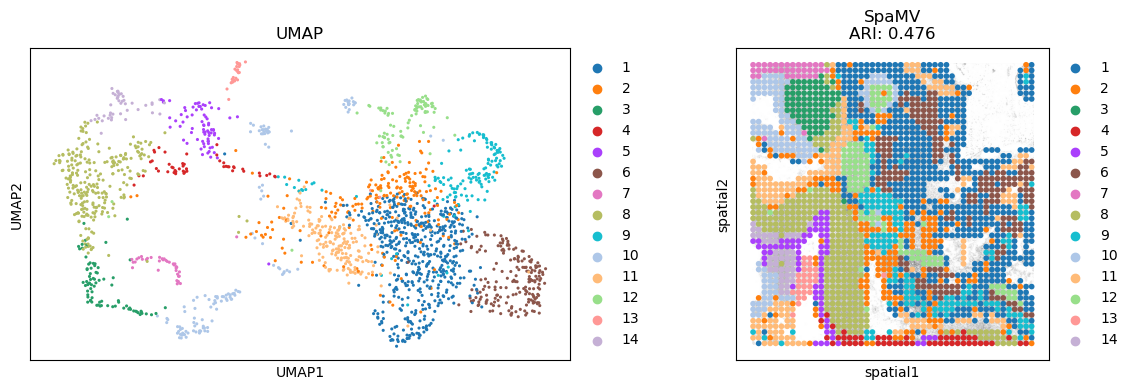

In [7]:
from sklearn.metrics import adjusted_rand_score

from SpaMV.spamv import SpaMV
from SpaMV.utils import preprocess_dc, clustering
import scanpy as sc
import matplotlib.pyplot as plt

dataname = 'Mouse_Embryo'
datafolder = 'Data/' + dataname
scale=False
if dataname == 'Mouse_Embryo':
    datasets = [sc.read_h5ad(datafolder + '/adata_RNA.h5ad'), sc.read_h5ad(datafolder + '/adata_peaks.h5ad')]
    omics_names = ['Transcriptome', 'Epigenome']
    n_cluster = 14
elif dataname == 'ME13_1':
    datasets = [sc.read_h5ad(datafolder + '/adata_H3K27ac_ATAC.h5ad'),
                sc.read_h5ad(datafolder + '/adata_H3K27me3_ATAC.h5ad')]
    omics_names = ['H3K27ac', 'H3K27me3']
    n_cluster = 21
elif dataname == 'Mouse_Thymus':
    datasets = [sc.read_h5ad(datafolder + '/adata_RNA.h5ad'), sc.read_h5ad(datafolder + '/adata_ADT.h5ad')]
    omics_names = ['Transcriptome', 'Proteome']
    n_cluster = 7
    scale=True
elif dataname == 'ccRCC_Y7_T':
    datasets = [sc.read_h5ad(datafolder + '/adata_RNA.h5ad'), sc.read_h5ad(datafolder + '/adata_MET.h5ad')]
    omics_names = ['Transcriptome', 'Metabolome']
    n_cluster = 16
else:
    raise NotImplementedError
datasets = preprocess_dc(datasets, omics_names, scale=scale)

model = SpaMV(datasets, interpretable=False)
model.train()

datasets[0].obsm['SpaMV'] = model.get_embedding()
clustering(datasets[0], n_clusters=n_cluster, key='SpaMV')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns
sc.pp.neighbors(datasets[0], use_rep='SpaMV')
sc.tl.umap(datasets[0])
sc.pl.umap(datasets[0], color='SpaMV', ax=axes[0], show=False, s=20, title='UMAP')
if 'spatial' in datasets[0].uns:
    sc.pl.spatial(datasets[0], color='SpaMV', title='SpaMV\nARI: {:.3f}'.format(
        adjusted_rand_score(datasets[0].obs['cluster'], datasets[0].obs['SpaMV'])) if 'cluster' in datasets[
            0].obs else 'SpaMV', show=False, ax=axes[1])
else:
    sc.pl.embedding(datasets[0], basis='spatial', color='SpaMV', show=False, ax=axes[1], size=50)
plt.tight_layout()
plt.show()

## Interpretable Dimension Reduction on Real-World Data

In [ ]:
from matplotlib import pyplot as plt
from SpaMV_copy.spamv import SpaMV
from SpaMV_copy.utils import plot_embedding_results, preprocess_idr
import scanpy as sc

dataname = 'ME13_1'
data_folder = 'Data/' + dataname
zs_dim = 10
threshold_background = 1
weights = [1, 1]
alphas = [1, 1]
if dataname in ['Mouse_Thymus']:
    data = [sc.read_h5ad(data_folder + '/adata_RNA.h5ad'), sc.read_h5ad(data_folder + '/adata_ADT.h5ad')]
    omics_names = ['Transcriptome', 'Proteome']
    zp_dims = [10, 10]
    weights = [1, 10]
    alphas = [5, 5]
elif dataname in ['Mouse_Embryo']:
    data = [sc.read_h5ad(data_folder + '/adata_RNA.h5ad'), sc.read_h5ad(data_folder + '/adata_ATAC.h5ad')]
    omics_names = ['Transcriptome', 'Epigenome']
    zp_dims = [15, 5]
elif dataname in ['ME13_1']:
    data = [sc.read_h5ad(data_folder + '/adata_H3K27ac_ATAC.h5ad'),
            sc.read_h5ad(data_folder + '/adata_H3K27me3_ATAC.h5ad')]
    omics_names = ['H3K27ac', 'H3K27me3']
    zs_dim = 20
    zp_dims = [5, 5]
    threshold_backgound = 5
elif dataname in ['ccRCC_Y7_T']:
    data = [sc.read_h5ad(data_folder + '/adata_RNA.h5ad'), sc.read_h5ad(data_folder + '/adata_MET.h5ad')]
    omics_names = ['Transcriptome', 'Metabolome']
    zp_dims = [5, 5]
else:
    raise Exception(f"Unkonwn Dataset: {dataname}")

data = preprocess_idr(data, omics_names)
model = SpaMV(data, zs_dim=zs_dim, zp_dims=zp_dims, interpretable=True, weights=weights, alphas=alphas,
              omics_names=omics_names, threshold_background=threshold_background, max_epochs_stage2=400)
model.train()
z, w = model.get_embedding_and_feature_by_topic()
if dataname == 'ccRCC_Y7_T':
    spatial_range = data[0].obsm['spatial'].min(0).tolist() + data[0].obsm['spatial'].max(0).tolist()
    width = spatial_range[2] - spatial_range[0]
    height = spatial_range[3] - spatial_range[1]
    crop_coord = [(spatial_range[0] - width / 20, spatial_range[1] - height / 20, spatial_range[2] + width / 20,
                   spatial_range[3] + height / 20)]
    plot_embedding_results(data, omics_names, z, w, show=True, save=False, crop_coord=crop_coord)
else:
    plot_embedding_results(data, omics_names, z, w, show=True, save=False, size=100)

plt.show()

/opt/anaconda3/envs/SpaMV/lib/python3.12/site-packages/scanpy/preprocessing/_simple.py:293: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number
